# Advanced Data Science – FA2 Case Study
## Employee Attrition Prediction using Machine Learning & Streamlit Deployment

**Student:** Shreya Prashant Deshmukh | **PRN:** 125M1H012
**Course:** Advanced Data Science [MCA33PE17] | **Department:** MCA | **Class:** SYMCA | **Academic Year:** 2026–2027 | **Semester:** I

**Case study:** Data Analysis Using Machine Learning & Streamlit App Deployment (Unit 1 – Unit 4)

---

### Problem statement
Predict whether an employee will **leave the company (attrition)** from HR data – job role, pay, overtime, tenure, satisfaction scores and demographics – and compare four classification algorithms. Replacing an employee is costly, so an early-warning model lets HR start retention conversations *before* a resignation.

### Dataset – *IBM HR Analytics Employee Attrition & Performance*
* **Source:** sample dataset created by IBM data scientists (fictional employees); published on Kaggle ("IBM HR Analytics Employee Attrition & Performance") and in IBM's public GitHub repository, which is the copy used here (`data/employee_attrition.csv`).
* **Size:** 1,470 employees × 35 columns – 34 descriptive features plus the target `Attrition` (Yes / No).
* **Feature types:** 26 numeric columns (age, income, tenure, 1–4 satisfaction ratings …) and 8 categorical columns (job role, department, overtime, marital status …).

### Why this dataset? (justification)
| Reason | Why it matters for this case study |
|---|---|
| Real business problem | Attrition is a classic HR-analytics task; the cost of the two error types differs (a missed leaver vs. an unnecessary retention conversation). |
| Mixed numeric + categorical data | Requires genuine preprocessing: one-hot encoding, scaling, and removal of constant / ID columns. |
| Strong class imbalance (≈ 16 % leave) | Accuracy is misleading (always answering "stays" gives ≈ 84 %), so precision, recall, F1 and PR-AUC are essential. |
| Hard, realistic prediction task | No single feature separates the classes, so model choice, tuning and honest evaluation actually matter. |
| Moderate size (1,470 rows) | `GridSearchCV` and K-fold CV on all four algorithms run in minutes. |
| Interpretable features | Each Streamlit input is a real HR attribute a user understands. |

### Algorithms compared (4 distinct algorithms)
1. Logistic Regression  2. Decision Tree  3. Random Forest  4. k-Nearest Neighbors (k-NN)

### Workflow
Data acquisition → EDA → preprocessing & stratified split → training with K-fold cross-validation → evaluation → `GridSearchCV` tuning (all four models) → threshold analysis → model saving for the Streamlit app (`app.py`).

> **Class convention.** The target is encoded **1 = employee leaves (Yes)**, **0 = stays (No)**. Precision, recall and F1 are reported for the **leaving** class, because finding the employees at risk is the purpose of the model.

## 0. Setup

In [1]:
# Import libraries -------------------------------------------------------------------------------
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, accuracy_score,
    average_precision_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")                        # keep the notebook output readable
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

RANDOM_STATE = 42                                        # one seed -> fully reproducible results
COLORS = {"Stays": "#2a9d8f", "Leaves": "#d1495b"}       # same colours in every plot

## 1. Data Acquisition & Inspection

In [2]:
# Load the dataset ---------------------------------------------------------------------------------
df = pd.read_csv("data/employee_attrition.csv")
df["Status"] = df["Attrition"].map({"No": "Stays", "Yes": "Leaves"})   # readable labels for plots

print(f"Shape: {df.shape[0]} employees x {df.shape[1] - 1} columns (incl. target 'Attrition')")
df.head()                                                # first rows of the data

Shape: 1470 employees x 35 columns (incl. target 'Attrition')


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Status
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,Leaves
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,Stays
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,Leaves
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,Stays
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,Stays


In [3]:
# Data types / non-null counts, then statistics for numeric and categorical columns
df.drop(columns="Status").info()
df.describe().T.round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


In [4]:
# Data-quality checks ----------------------------------------------------------------------------
print("Missing values (total):", int(df.isnull().sum().sum()))
print("Duplicate rows:        ", int(df.duplicated().sum()))

categorical = df.drop(columns=["Attrition", "Status"]).select_dtypes("object").columns.tolist()
print("Categorical columns:   ", categorical)

constant = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns (no information):", constant)
print("ID-like column: EmployeeNumber ->", df["EmployeeNumber"].nunique(), "unique values for", len(df), "rows")

Missing values (total): 0
Duplicate rows:         0
Categorical columns:    ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Constant columns (no information): ['EmployeeCount', 'Over18', 'StandardHours']
ID-like column: EmployeeNumber -> 1470 unique values for 1470 rows


## 2. Exploratory Data Analysis (EDA)
### 2.1 Class balance

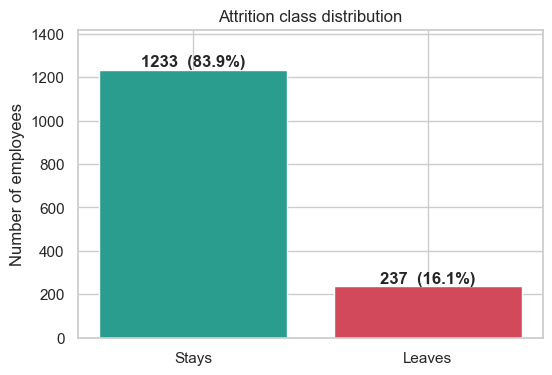

In [5]:
counts = df["Status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[c] for c in counts.index])
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 15, f"{n}  ({n / len(df):.1%})", ha="center", fontweight="bold")
ax.set(title="Attrition class distribution", ylabel="Number of employees", ylim=(0, counts.max() * 1.15))
plt.show()

### 2.2 Attrition rate by categorical features

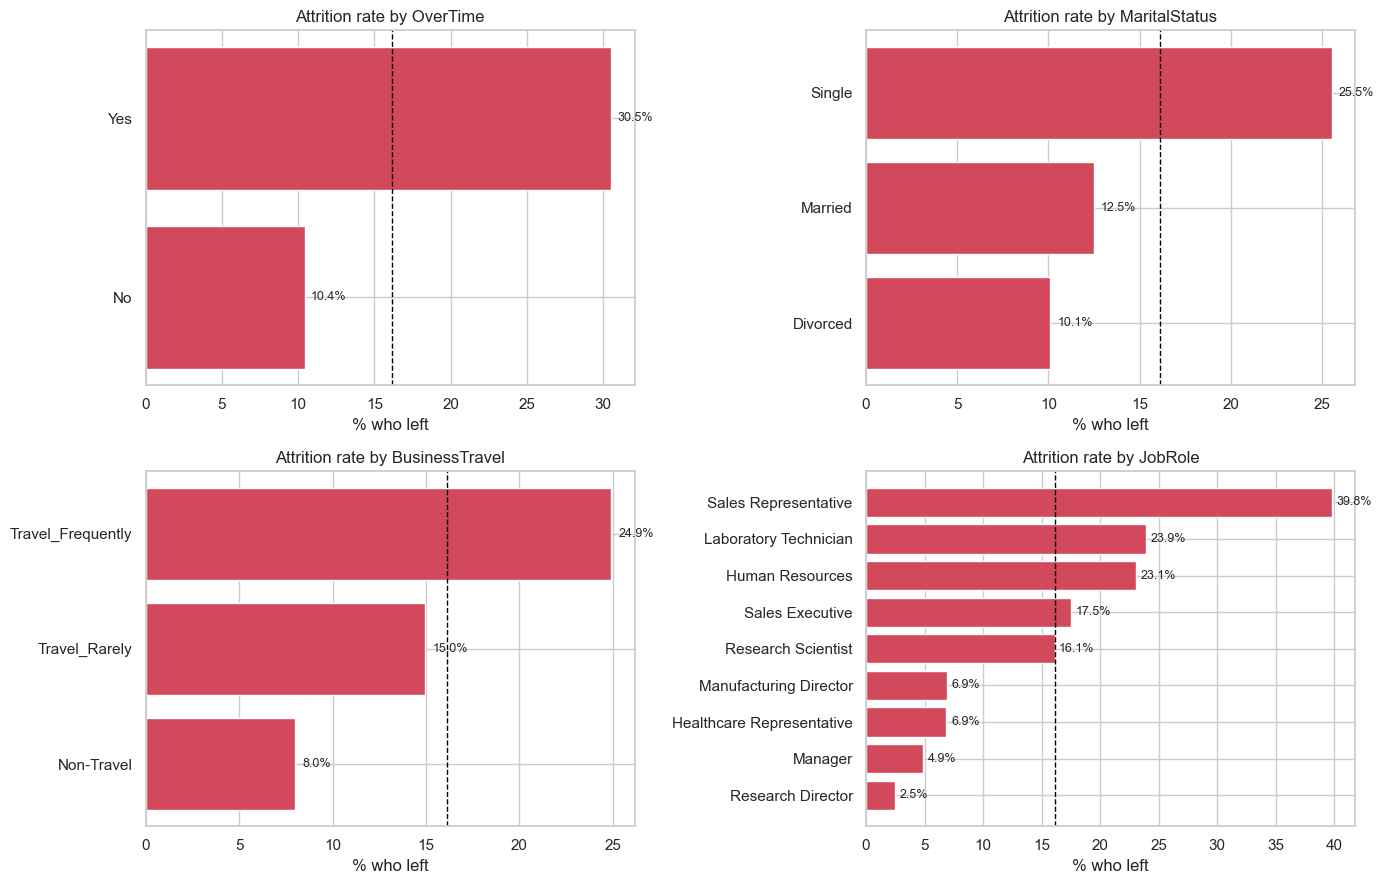

In [6]:
# Share of employees who left within each category (red line = overall 16.1 %)
overall = (df["Attrition"] == "Yes").mean() * 100
cat_plot = ["OverTime", "MaritalStatus", "BusinessTravel", "JobRole"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cat_plot):
    rate = df.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
    ax.barh(rate.index, rate.values, color="#d1495b")
    ax.axvline(overall, color="black", ls="--", lw=1)
    for y_pos, v in enumerate(rate.values):
        ax.text(v + 0.4, y_pos, f"{v:.1f}%", va="center", fontsize=9)
    ax.set(title=f"Attrition rate by {col}", xlabel="% who left")
plt.tight_layout()
plt.show()

### 2.3 Numeric features: leavers vs. stayers

Status,Stays,Leaves,Leaves / Stays
Age,36.0,32.0,0.89
MonthlyIncome,5204.0,3202.0,0.62
YearsAtCompany,6.0,3.0,0.50
TotalWorkingYears,10.0,7.0,0.70
DistanceFromHome,7.0,9.0,1.29
YearsSinceLastPromotion,1.0,1.0,1.00


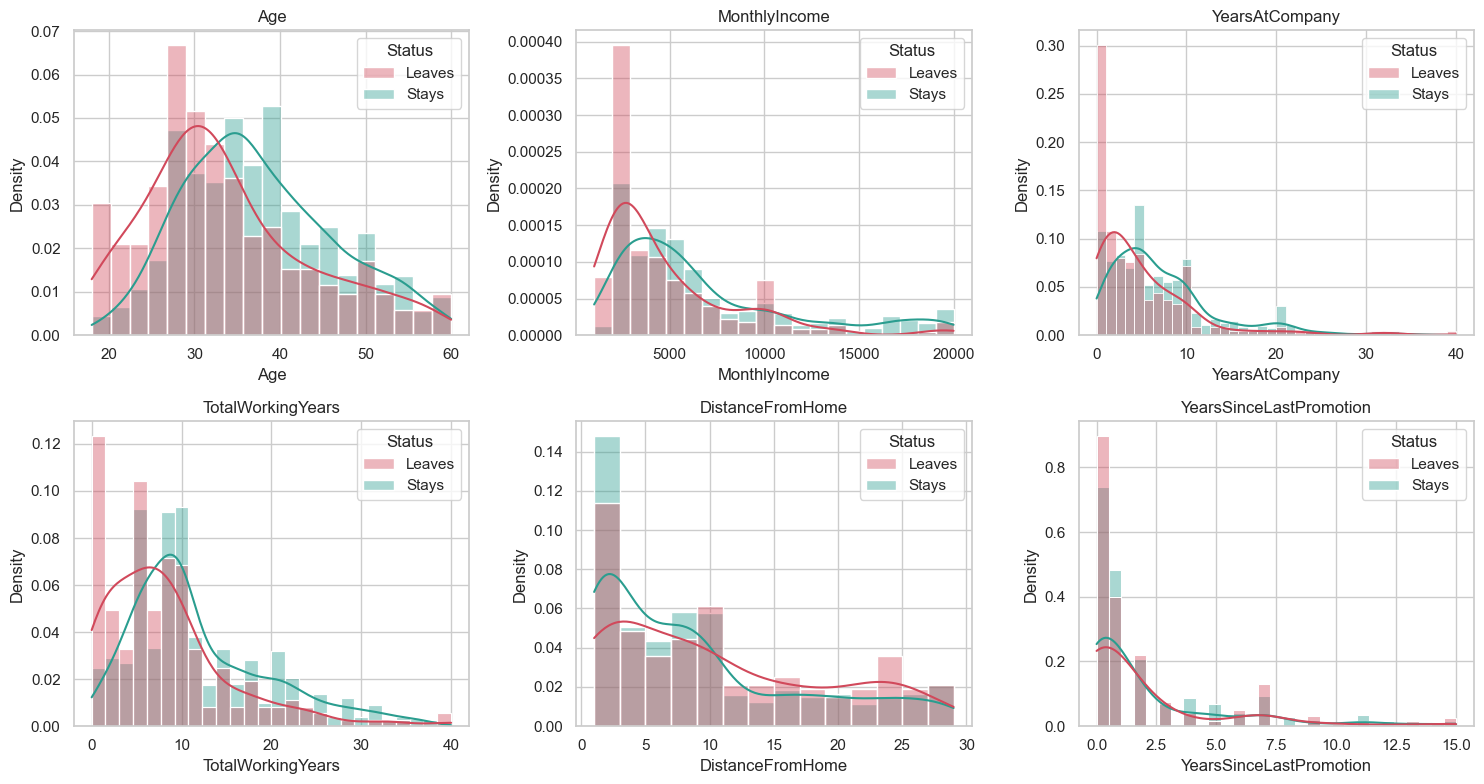

In [7]:
key_numeric = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "DistanceFromHome", "YearsSinceLastPromotion"]

# Median comparison table
cmp = df.groupby("Status")[key_numeric].median().T[["Stays", "Leaves"]]
cmp["Leaves / Stays"] = (cmp["Leaves"] / cmp["Stays"]).round(2)
display(cmp.round(2))

# Distributions: the less the two curves overlap, the more useful the feature
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_numeric):
    sns.histplot(data=df, x=col, hue="Status", palette=COLORS, kde=True, stat="density",
                 common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

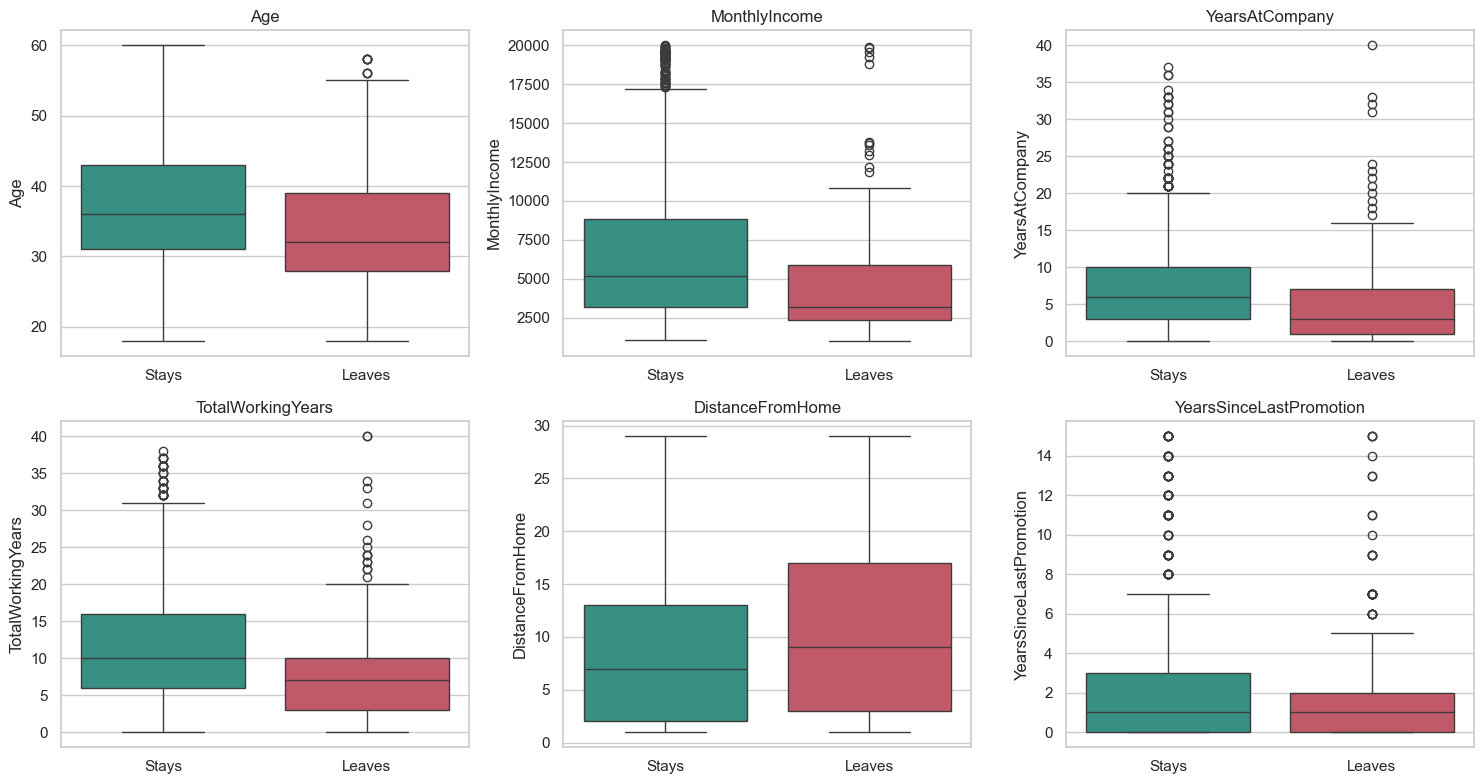

In [8]:
# Box plots (spread and outliers per class)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_numeric):
    sns.boxplot(data=df, x="Status", y=col, hue="Status", order=["Stays", "Leaves"],
                palette=COLORS, legend=False, ax=ax)
    ax.set(title=col, xlabel="")
plt.tight_layout()
plt.show()

### 2.4 Which numeric features relate to attrition? Which are redundant?

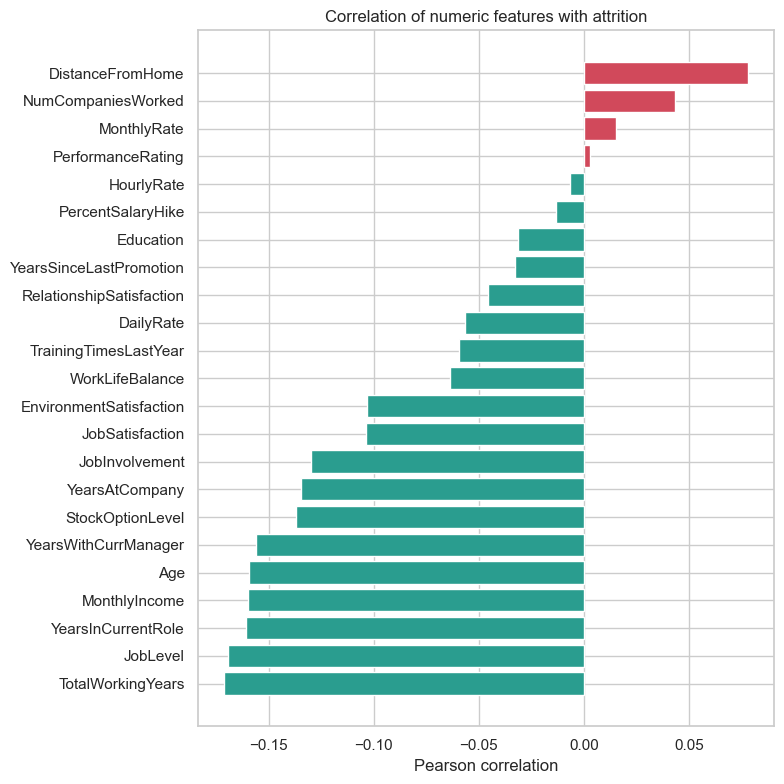

Strongest negative: {'TotalWorkingYears': -0.171, 'JobLevel': -0.169, 'YearsInCurrentRole': -0.161, 'MonthlyIncome': -0.16}
Strongest positive: {'MonthlyRate': 0.015, 'NumCompaniesWorked': 0.043, 'DistanceFromHome': 0.078}


In [9]:
numeric_cols = [c for c in df.select_dtypes("number").columns if c not in ["EmployeeCount", "StandardHours", "EmployeeNumber"]]
y_bin = (df["Attrition"] == "Yes").astype(int)

corr_target = df[numeric_cols].corrwith(y_bin).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(corr_target.index, corr_target.values,
        color=np.where(corr_target.values > 0, COLORS["Leaves"], COLORS["Stays"]))
ax.set(title="Correlation of numeric features with attrition", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()
print("Strongest negative:", corr_target.head(4).round(3).to_dict())
print("Strongest positive:", corr_target.tail(3).round(3).to_dict())

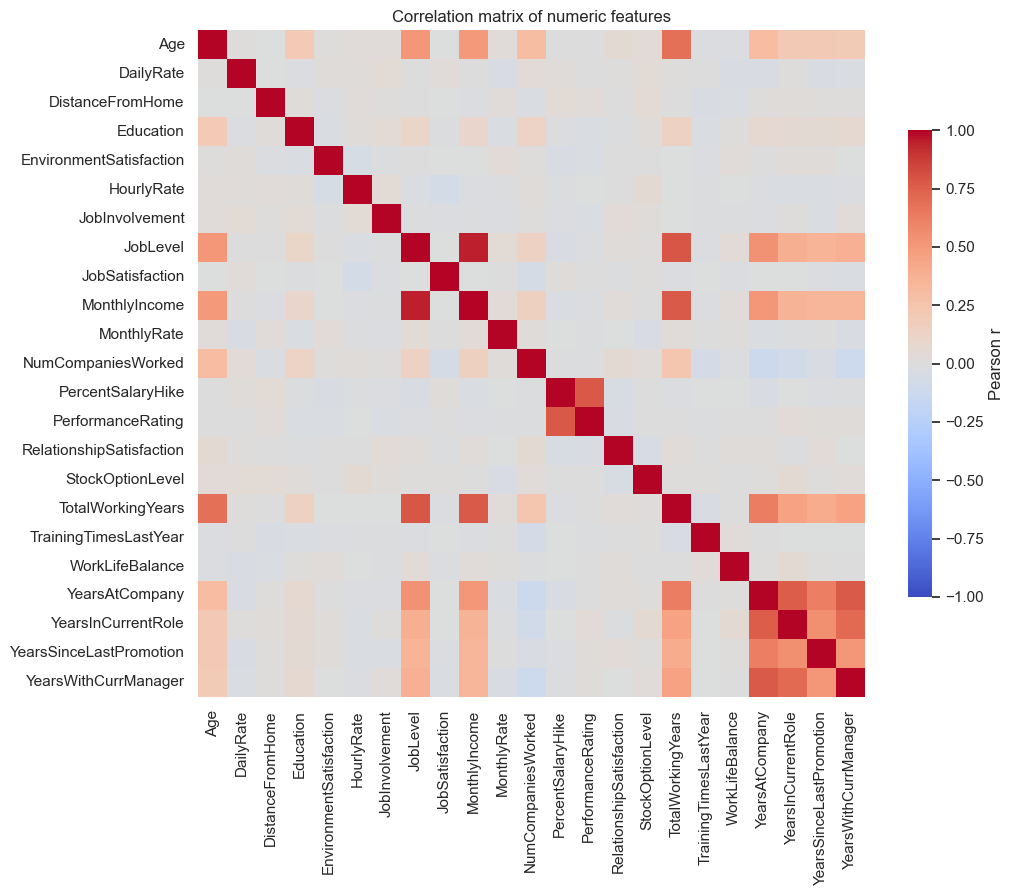

7 of 253 numeric feature pairs have |r| > 0.7:


,feature_1,feature_2,r
134,JobLevel,MonthlyIncome,0.950
141,JobLevel,TotalWorkingYears,0.782
198,PercentSalaryHike,PerformanceRating,0.774
168,MonthlyIncome,TotalWorkingYears,0.773
249,YearsAtCompany,YearsWithCurrManager,0.769
247,YearsAtCompany,YearsInCurrentRole,0.759
251,YearsInCurrentRole,YearsWithCurrManager,0.714


In [10]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().rename("r").reset_index()
pairs.columns = ["feature_1", "feature_2", "r"]
high = pairs[pairs["r"].abs() > 0.7].sort_values("r", ascending=False)
print(f"{len(high)} of {len(pairs)} numeric feature pairs have |r| > 0.7:")
high.round(3)

### 2.5 Outliers and skewness (IQR rule)

In [11]:
X_num = df[numeric_cols]
q1, q3 = X_num.quantile(0.25), X_num.quantile(0.75)
iqr = q3 - q1
is_outlier = (X_num < q1 - 1.5 * iqr) | (X_num > q3 + 1.5 * iqr)
print(f"Flagged values: {int(is_outlier.values.sum())} | rows with at least one outlier: {int(is_outlier.any(axis=1).sum())} of {len(df)}")
pd.DataFrame({"outliers": is_outlier.sum(), "skewness": X_num.skew().round(2)}).sort_values("outliers", ascending=False).head(8)

Flagged values: 1024 | rows with at least one outlier: 691 of 1470


,outliers,skewness
TrainingTimesLastYear,238,0.55
PerformanceRating,226,1.92
MonthlyIncome,114,1.37
YearsSinceLastPromotion,107,1.98
YearsAtCompany,104,1.76
StockOptionLevel,85,0.97
TotalWorkingYears,63,1.12
NumCompaniesWorked,52,1.03


### 2.6 EDA summary – findings, insights and challenges
1. **Clean but imbalanced data.** No missing values, no duplicates. Only 237 of 1,470 employees (16.1 %) left, so a model that always predicts "stays" scores 83.9 % accuracy while finding nobody → accuracy is misleading; we use precision, recall, F1, PR-AUC and a **stratified** split.
2. **Useless columns.** `EmployeeCount`, `StandardHours` and `Over18` are constant, and `EmployeeNumber` is just an ID – all four are dropped.
3. **Overtime is the strongest single signal.** 30.5 % of employees who work overtime left vs. 10.4 % of those who do not. Frequent business travellers leave at 24.9 % (vs. 8.0 % for non-travellers) and single employees at 25.5 % (vs. 10.1–12.5 % for divorced / married).
4. **Role matters a lot.** Sales Representatives (39.8 %) and Laboratory Technicians (23.9 %) leave far more than Managers (4.9 %) and Research Directors (2.5 %); employees with no stock options (24.4 %) and entry-level (Job Level 1, 26.3 %) staff are also at higher risk.
5. **Leavers are younger, earlier in their careers and paid less.** Median monthly income is 3,202 for leavers vs. 5,204 for stayers, median age 32 vs. 36 and median tenure 3 vs. 6 years.
6. **No single numeric feature is decisive.** Every numeric correlation with attrition is weak (|r| ≤ 0.17; strongest: total working years −0.17, job level −0.17, years in current role −0.16, monthly income −0.16). This is a genuinely *hard* prediction problem and combinations of features are needed.
7. **Some redundancy.** 7 of 253 numeric pairs have |r| > 0.7 (e.g. job level ↔ monthly income, total working years ↔ job level / age, years at company ↔ years in current role) – harmless for trees, handled by regularisation in Logistic Regression.
8. **Skewed, outlier-containing features** (e.g. years since last promotion, years at company, monthly income). The outliers are real employees (long tenure, high pay), so they are **kept**; scaling is applied for the distance / gradient-based models.

## 3. Data Preprocessing
| Step | Decision |
|---|---|
| **Drop useless columns** | `EmployeeCount`, `StandardHours`, `Over18` (constant) and `EmployeeNumber` (ID) carry no information. |
| **Missing values** | None exist; a median (numeric) / most-frequent (categorical) `SimpleImputer` is still the first step so the deployed model cannot fail on a blank input. |
| **Target encoding** | `Attrition`: Yes → 1, No → 0. |
| **Categorical features** | 7 nominal columns are **one-hot encoded** (`OneHotEncoder`, unknown categories ignored). Label encoding would invent a false order between e.g. job roles. |
| **Scaling** | `StandardScaler` on numeric features for Logistic Regression and k-NN (scale-sensitive). Trees are scale-invariant and left unscaled. |
| **Leakage control** | All preprocessing sits in a `ColumnTransformer` inside a `Pipeline`, fitted on training data only (and re-fitted in every CV fold). |
| **Split** | 80 % train / 20 % test, **stratified** on the target, fixed seed. |

In [12]:
# Build X / y: drop constant + ID columns, encode the target ---------------------------------------
y = (df["Attrition"] == "Yes").astype(int)                       # 1 = leaves, 0 = stays
X = df.drop(columns=["Attrition", "Status", "EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print(f"{X.shape[1]} input features: {len(num_cols)} numeric + {len(cat_cols)} categorical")
print("Categorical columns and their levels:", {c: X[c].nunique() for c in cat_cols})
print("One-hot encoding expands them to", len(num_cols) + sum(X[c].nunique() for c in cat_cols), "model features")

30 input features: 23 numeric + 7 categorical
Categorical columns and their levels: {'BusinessTravel': 3, 'Department': 3, 'EducationField': 6, 'Gender': 2, 'JobRole': 9, 'MaritalStatus': 3, 'OverTime': 2}
One-hot encoding expands them to 51 model features


In [13]:
# Why scaling matters: feature scales differ by orders of magnitude
spread = X[num_cols].std()
print(f"Smallest std: {spread.min():.2f} ({spread.idxmin()})   Largest std: {spread.max():.0f} ({spread.idxmax()})")

# Stratified 80/20 split ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
pd.DataFrame({"employees": [len(y_train), len(y_test)],
              "% leaving": [y_train.mean() * 100, y_test.mean() * 100],
              "leavers": [int(y_train.sum()), int(y_test.sum())]},
             index=["train (80%)", "test (20%)"]).round(1)

Smallest std: 0.36 (PerformanceRating)   Largest std: 7118 (MonthlyRate)


,employees,% leaving,leavers
train (80%),1176,16.2,190
test (20%),294,16.0,47


## 4. Model Implementation & Training
Four distinct algorithms, each inside a full pipeline (`preprocessing → model`). Baselines use default hyper-parameters; **no class weighting** yet – imbalance handling is explored during tuning.

In [14]:
def make_pipeline(estimator, scale):
    """ColumnTransformer (impute + optional scale numerics, impute + one-hot categoricals) -> estimator."""
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scaler", StandardScaler()))
    prep = ColumnTransformer([
        ("num", Pipeline(numeric_steps), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ])
    return Pipeline([("prep", prep), ("model", estimator)])


baseline_models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE), scale=True),
    "Decision Tree":       make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
    "Random Forest":       make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), scale=False),
    "k-NN":                make_pipeline(KNeighborsClassifier(), scale=True),
}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)                          # train on the 80 % training split only
    print(f"{name:<20} trained")

Logistic Regression  trained
Decision Tree        trained


Random Forest        trained


k-NN                 trained


### 4.1 Stability check with stratified 5-fold cross-validation
Each baseline is scored with **stratified 5-fold cross-validation on the training data** (mean ± std = expected performance and stability). A large gap between train and CV accuracy signals over-fitting.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)    # shared by CV and GridSearchCV
scoring = {"accuracy": "accuracy", "f1": "f1", "recall": "recall"}            # f1 / recall of the "leaves" class

cv_results = {name: cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
              for name, model in baseline_models.items()}

pm = lambda s: f"{s.mean():.3f} ± {s.std():.3f}"
cv_table = pd.DataFrame({
    name: {"Train accuracy": round(r["train_accuracy"].mean(), 3),
           "CV accuracy": pm(r["test_accuracy"]),
           "CV F1 (leaves)": pm(r["test_f1"]),
           "CV recall (leaves)": pm(r["test_recall"])}
    for name, r in cv_results.items()
}).T
cv_table

,Train accuracy,CV accuracy,CV F1 (leaves),CV recall (leaves)
Logistic Regression,0.9,0.890 ± 0.019,0.561 ± 0.098,0.442 ± 0.096
Decision Tree,1.0,0.794 ± 0.017,0.356 ± 0.081,0.358 ± 0.102
Random Forest,1.0,0.863 ± 0.007,0.315 ± 0.078,0.200 ± 0.061
k-NN,0.876,0.852 ± 0.015,0.228 ± 0.126,0.142 ± 0.086


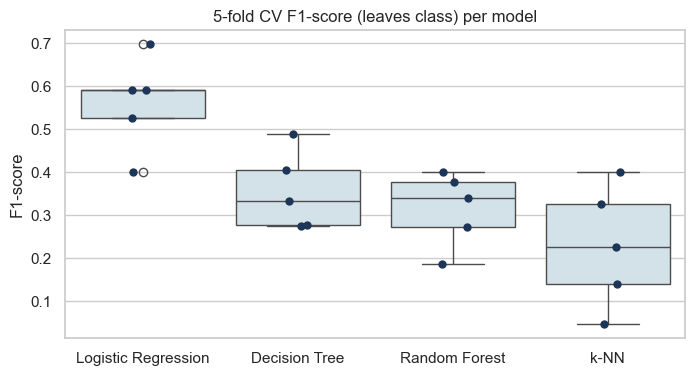

In [16]:
fold_f1 = pd.DataFrame({name: r["test_f1"] for name, r in cv_results.items()})
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=fold_f1, color="#cfe3ec", ax=ax)
sns.stripplot(data=fold_f1, color="#1d3557", size=6, ax=ax)
ax.set(title="5-fold CV F1-score (leaves class) per model", ylabel="F1-score", xlabel="")
plt.show()

## 5. Model Evaluation (baseline models, unseen test set)
Metrics for the **leaving** class (positive = 1):
* **Precision** – of the employees flagged as likely to leave, how many really left.
* **Recall** – of the employees who really left, how many were flagged (*missed leavers* = false negatives).
* **F1** – harmonic mean of precision and recall. **ROC-AUC** – ranking quality; **PR-AUC** (average precision) – ranking quality focused on the rare class (a random model scores ≈ 0.16).

In [17]:
def evaluate(model, X_eval, y_eval):
    """Test-set metrics with *leaves* as the positive class."""
    y_pred = model.predict(X_eval)
    p_leave = model.predict_proba(X_eval)[:, 1]
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])           # rows = truth, cols = prediction
    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1-Score": f1_score(y_eval, y_pred),
        "ROC-AUC": roc_auc_score(y_eval, p_leave),
        "PR-AUC": average_precision_score(y_eval, p_leave),
        "Missed leavers (FN)": int(cm[1, 0]),
        "False alarms (FP)": int(cm[0, 1]),
    }


COUNT_COLS = {"Missed leavers (FN)": int, "False alarms (FP)": int}
baseline_df = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in baseline_models.items()}).T.astype(COUNT_COLS)
print(f"Test set: {len(y_test)} employees, {int(y_test.sum())} of whom left")
baseline_df.sort_values("F1-Score", ascending=False).round(4)

Test set: 294 employees, 47 of whom left


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Missed leavers (FN),False alarms (FP)
Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.8115,0.5836,31,10
Decision Tree,0.7653,0.3103,0.3830,0.3429,0.6105,0.2175,29,40
Random Forest,0.8503,0.6364,0.1489,0.2414,0.7843,0.4693,40,4
k-NN,0.8435,0.5385,0.1489,0.2333,0.5946,0.2734,40,6


In [18]:
# Classification report for every baseline model
for name, model in baseline_models.items():
    print("=" * 66, f"\n{name}\n" + "=" * 66)
    print(classification_report(y_test, model.predict(X_test), target_names=["Stays", "Leaves"], digits=3))

Logistic Regression
              precision    recall  f1-score   support

       Stays      0.884     0.960     0.920       247
      Leaves      0.615     0.340     0.438        47

    accuracy                          0.861       294
   macro avg      0.750     0.650     0.679       294
weighted avg      0.841     0.861     0.843       294

Decision Tree
              precision    recall  f1-score   support

       Stays      0.877     0.838     0.857       247
      Leaves      0.310     0.383     0.343        47

    accuracy                          0.765       294
   macro avg      0.594     0.611     0.600       294
weighted avg      0.787     0.765     0.775       294

Random Forest
              precision    recall  f1-score   support

       Stays      0.859     0.984     0.917       247
      Leaves      0.636     0.149     0.241        47

    accuracy                          0.850       294
   macro avg      0.748     0.566     0.579       294
weighted avg      0.823   

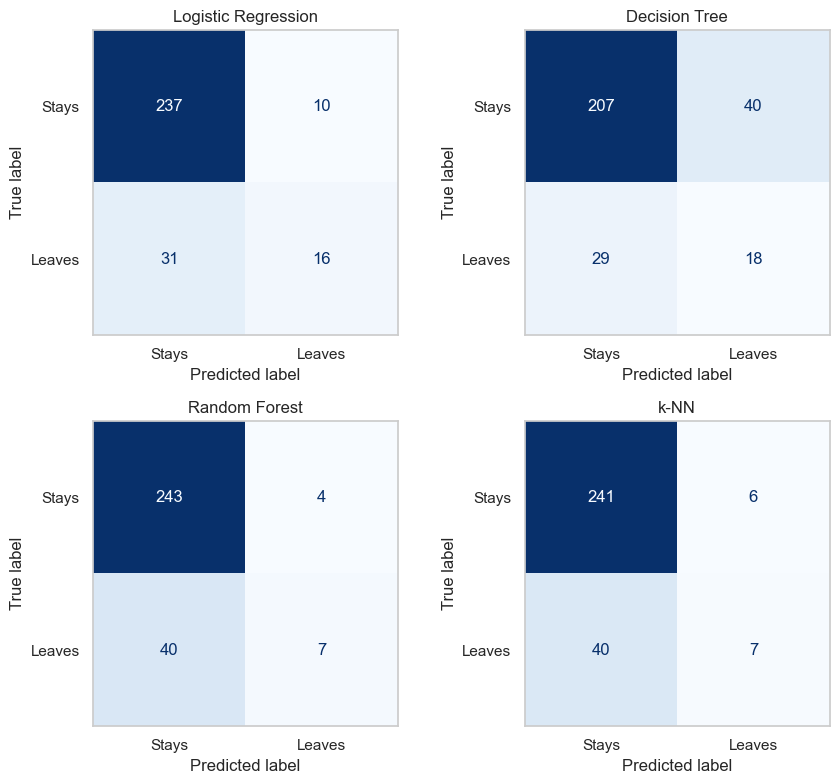

In [19]:
# Confusion matrices (rows = actual, columns = predicted)
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (name, model) in zip(axes.ravel(), baseline_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Stays", "Leaves"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

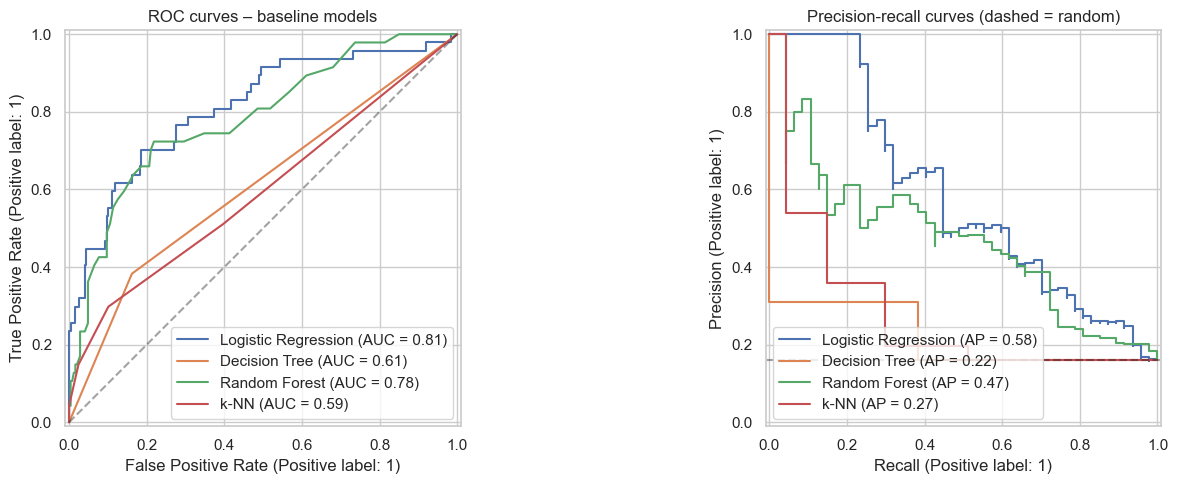

In [20]:
# ROC and precision-recall curves for the baseline models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for name, model in baseline_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax1)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax2)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_title("ROC curves – baseline models")
ax2.axhline(y_test.mean(), color="k", ls="--", alpha=0.4)
ax2.set_title("Precision-recall curves (dashed = random)")
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning with GridSearchCV
`GridSearchCV` is applied to **all four models**. Each parameter combination is scored by stratified 5-fold CV on the **training data only**, using the **F1-score of the leaving class**; the winner is re-fitted on the whole training set. For the tree models and Logistic Regression the grid also tests `class_weight="balanced"` (re-weights the rare "leaves" class). The test set is *not* used to choose parameters.

In [21]:
# Parameter names use the "model__" prefix because the estimator sits inside a Pipeline
param_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10],
                            "model__class_weight": [None, "balanced"]},
    "Decision Tree":       {"model__max_depth": [3, 4, 5, 6, 8, None],
                            "model__min_samples_leaf": [1, 5, 10, 20],
                            "model__class_weight": [None, "balanced"]},
    "Random Forest":       {"model__n_estimators": [100, 300],
                            "model__max_depth": [None, 8, 12],
                            "model__min_samples_leaf": [1, 3],
                            "model__class_weight": [None, "balanced", "balanced_subsample"]},
    "k-NN":                {"model__n_neighbors": [3, 5, 7, 11, 15, 21],
                            "model__weights": ["uniform", "distance"],
                            "model__p": [1, 2]},
}

searches, tuning_rows = {}, []
for name, model in baseline_models.items():
    search = GridSearchCV(model, param_grids[name], cv=cv, scoring="f1", n_jobs=1)
    search.fit(X_train, y_train)
    searches[name] = search

    base_cv_f1 = cv_results[name]["test_f1"].mean()
    tuning_rows.append({
        "Model": name,
        "Combinations": len(search.cv_results_["params"]),
        "Best parameters": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
        "Baseline CV F1": round(base_cv_f1, 4),
        "Tuned CV F1": round(search.best_score_, 4),
        "Gain": round(search.best_score_ - base_cv_f1, 4),
    })

tuning_df = pd.DataFrame(tuning_rows).set_index("Model")
for name, row in tuning_df.iterrows():
    print(f"{name:<20} best params: {row['Best parameters']}")
tuning_df

Logistic Regression  best params: {'C': 1, 'class_weight': None}
Decision Tree        best params: {'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 10}
Random Forest        best params: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
k-NN                 best params: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}


,Combinations,Best parameters,Baseline CV F1,Tuned CV F1,Gain
Model,,,,,
Logistic Regression,8,"{'C': 1, 'class_weight': None}",0.5610,0.5610,0.0000
Decision Tree,48,"{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 10}",0.3556,0.4288,0.0732
Random Forest,36,"{'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}",0.3153,0.4504,0.1350
k-NN,24,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.2282,0.2798,0.0516


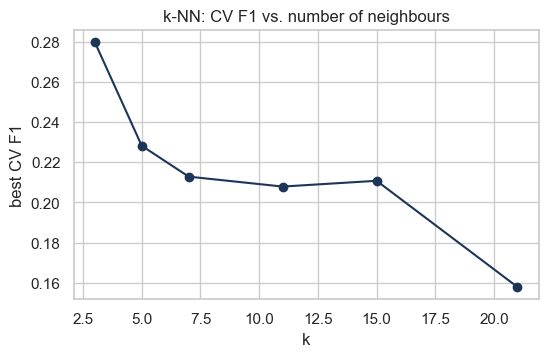

In [22]:
# Effect of the k-NN neighbourhood size on cross-validated F1 (best of weights / p for each k)
res = pd.DataFrame(searches["k-NN"].cv_results_)
res["k"] = res["param_model__n_neighbors"].astype(int)
curve = res.groupby("k")["mean_test_score"].max()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(curve.index, curve.values, marker="o", color="#1d3557")
ax.set(title="k-NN: CV F1 vs. number of neighbours", xlabel="k", ylabel="best CV F1")
plt.show()

In [23]:
# Tuned models (best estimator of each search) evaluated ONCE on the untouched test set
tuned_models = {name: search.best_estimator_ for name, search in searches.items()}
tuned_df = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in tuned_models.items()}).T.astype(COUNT_COLS)
tuned_df.sort_values("F1-Score", ascending=False).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Missed leavers (FN),False alarms (FP)
Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.8115,0.5836,31,10
Decision Tree,0.7279,0.3012,0.5319,0.3846,0.7038,0.3320,22,58
k-NN,0.8469,0.5455,0.2553,0.3478,0.6642,0.3434,35,10
Random Forest,0.8265,0.4333,0.2766,0.3377,0.7815,0.4333,34,17


## 7. Final Model Comparison

In [24]:
final_df = (pd.concat([baseline_df.assign(Version="Baseline"), tuned_df.assign(Version="Tuned")])
              .rename_axis("Model").reset_index()
              .sort_values(["F1-Score", "ROC-AUC"], ascending=False)
              .set_index(["Model", "Version"]))
final_df.round(4)

Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  Missed leavers (FN)  False alarms (FP)
Model               Version                                                                                                 
Logistic Regression Baseline    0.8605     0.6154  0.3404    0.4384   0.8115  0.5836                   31                 10
                    Tuned       0.8605     0.6154  0.3404    0.4384   0.8115  0.5836                   31                 10
Decision Tree       Tuned       0.7279     0.3012  0.5319    0.3846   0.7038  0.3320                   22                 58
k-NN                Tuned       0.8469     0.5455  0.2553    0.3478   0.6642  0.3434                   35                 10
Decision Tree       Baseline    0.7653     0.3103  0.3830    0.3429   0.6105  0.2175                   29                 40
Random Forest       Tuned       0.8265     0.4333  0.2766    0.3377   0.7815  0.4333                   34                 17
                    Baseline    0.8503     0.6364  0.1489    0.2414   0.7843  0.4693                   40                  4
k-NN                Baseline    0.8435     0.5385  0.1489    0.2333   0.5946  0.2734                   40                  6

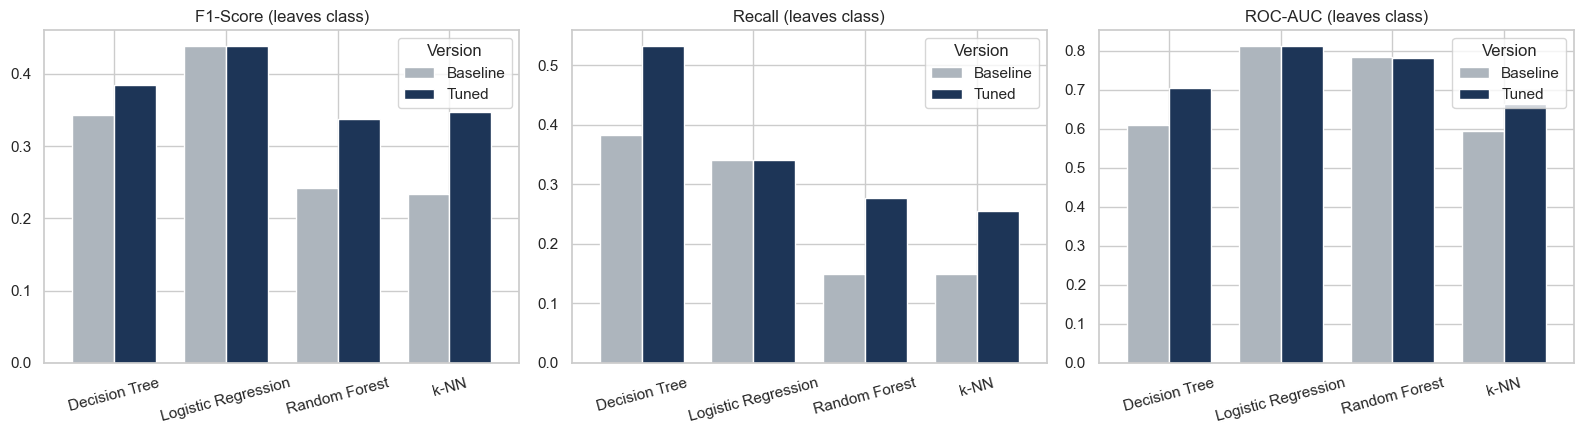

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["F1-Score", "Recall", "ROC-AUC"]):
    (final_df[metric].unstack("Version")[["Baseline", "Tuned"]]
        .plot.bar(ax=ax, rot=15, color=["#adb5bd", "#1d3557"], width=0.75))
    ax.set(title=f"{metric} (leaves class)", xlabel="")
plt.tight_layout()
plt.show()

### 7.1 Analysis of results

**Test set (294 employees, 47 leavers; positive class = leaves)**

| Model (tuned) | Baseline F1 → Tuned F1 | Baseline CV F1 → Tuned CV F1 | Recall (tuned) | Missed leavers → | False alarms | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|---|
| **Logistic Regression** (C = 1) | 0.438 → 0.438 | 0.561 → 0.561 | 0.340 | 31 | 10 | **0.812** | **0.584** |
| **Decision Tree** (depth 4, leaf ≥ 10, balanced) | 0.343 → 0.385 | 0.356 → 0.429 | 0.532 | 22 | 58 | 0.704 | 0.332 |
| **Random Forest** (depth 8, leaf ≥ 3, balanced) | 0.241 → 0.338 | 0.315 → 0.450 | 0.277 | 34 | 17 | 0.781 | 0.433 |
| **k-NN** (k = 3, Manhattan) | 0.233 → 0.348 | 0.228 → 0.280 | 0.255 | 35 | 10 | 0.664 | 0.343 |

**Key observations**

1. **Accuracy hides the real picture.** All models reach 73–86 % accuracy, yet the best one still misses over half of the leavers at the default 0.5 threshold. This is a hard, imbalanced task – precision / recall / F1 / PR-AUC are the meaningful metrics.
2. **Logistic Regression is clearly best** on cross-validated F1 (0.561), ROC-AUC (0.812) and PR-AUC (0.584, vs. 0.16 for a random model). The signal is mostly additive (overtime, travel, role, income, tenure), which a regularised linear model captures well from only 1,176 training rows.
3. **Trees over-fit.** The untuned Decision Tree and Random Forest score **100 % on training folds** but only 79 % / 86 % in CV (section 4.1). Random Forest's high accuracy is mainly because it predicts "stays" for almost everyone (recall 15 % at baseline).
4. **Tuning helps the weaker models most.** CV F1 rises from 0.356 → 0.429 (Decision Tree), 0.315 → 0.450 (Random Forest) and 0.228 → 0.280 (k-NN). The winning grids for both tree models use `class_weight="balanced"` and limited depth – the two classic cures for imbalance and over-fitting. Logistic Regression's grid kept the defaults, so its result is unchanged.
5. **Recall vs. false alarms.** The tuned Decision Tree finds the most leavers (recall 53 %) but raises 58 false alarms; Logistic Regression is far more precise (62 %). Which is "better" depends on how costly a retention conversation is compared with losing the employee.
6. **k-NN is weakest**: distances over 51 one-hot / scaled features are dominated by noise, and the F1-optimal k = 3 gives a poor ROC-AUC (0.664).
7. **Small test set:** with only 47 leavers, one employee is 2.1 points of recall, so differences between the three weaker models are within noise; the clear conclusion is *Logistic Regression ≫ the rest*.

## 8. Decision-Threshold Analysis (business view of the best model)
A classifier outputs a *probability*; the default cut-off of 0.5 is rarely right for a rare class. Lowering the cut-off flags more employees, trading precision for recall. (The table is computed on the test set for illustration – in practice the threshold would be chosen with cross-validation on training data.)

,Flagged employees,Precision,Recall,F1-Score,Leavers caught,Leavers missed
Threshold,,,,,,
0.50,26,0.615,0.340,0.438,16,31
0.40,34,0.618,0.447,0.519,21,26
0.30,48,0.500,0.511,0.505,24,23
0.25,58,0.500,0.617,0.552,29,18
0.20,71,0.423,0.638,0.508,30,17


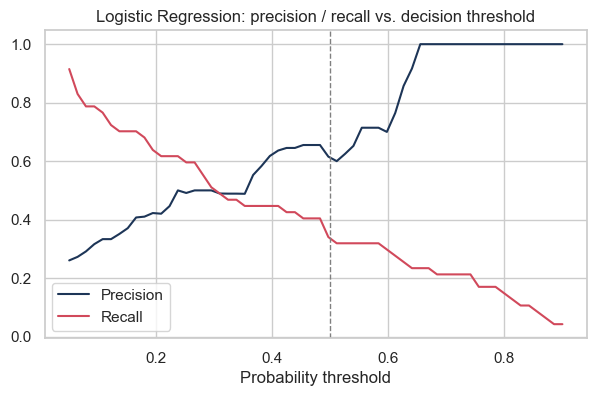

In [26]:
best_name = "Logistic Regression"
p_leave = tuned_models[best_name].predict_proba(X_test)[:, 1]

rows = []
for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    pred = (p_leave >= t).astype(int)
    rows.append({"Threshold": t,
                 "Flagged employees": int(pred.sum()),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1-Score": f1_score(y_test, pred),
                 "Leavers caught": int(((pred == 1) & (y_test == 1)).sum()),
                 "Leavers missed": int(((pred == 0) & (y_test == 1)).sum())})
threshold_df = pd.DataFrame(rows).set_index("Threshold")
display(threshold_df.round(3))

grid_t = np.linspace(0.05, 0.9, 60)
prec = [precision_score(y_test, (p_leave >= t).astype(int), zero_division=0) for t in grid_t]
rec = [recall_score(y_test, (p_leave >= t).astype(int)) for t in grid_t]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid_t, prec, label="Precision", color="#1d3557")
ax.plot(grid_t, rec, label="Recall", color="#d1495b")
ax.axvline(0.5, color="gray", ls="--", lw=1)
ax.set(title=f"{best_name}: precision / recall vs. decision threshold", xlabel="Probability threshold")
ax.legend()
plt.show()

**Business reading:** at the default 0.5 threshold HR would catch only 16 of the 47 leavers (recall 34 %). Lowering the threshold to **0.25** catches **29 of 47 (recall 62 %)** at 50 % precision – HR would talk to 58 of 294 employees (20 %) to reach most of the people at risk, and F1 improves from 0.44 to 0.55. This is a much more useful operating point than the default.

### 8.1 What drives attrition? (Logistic Regression coefficients and Random Forest importances)

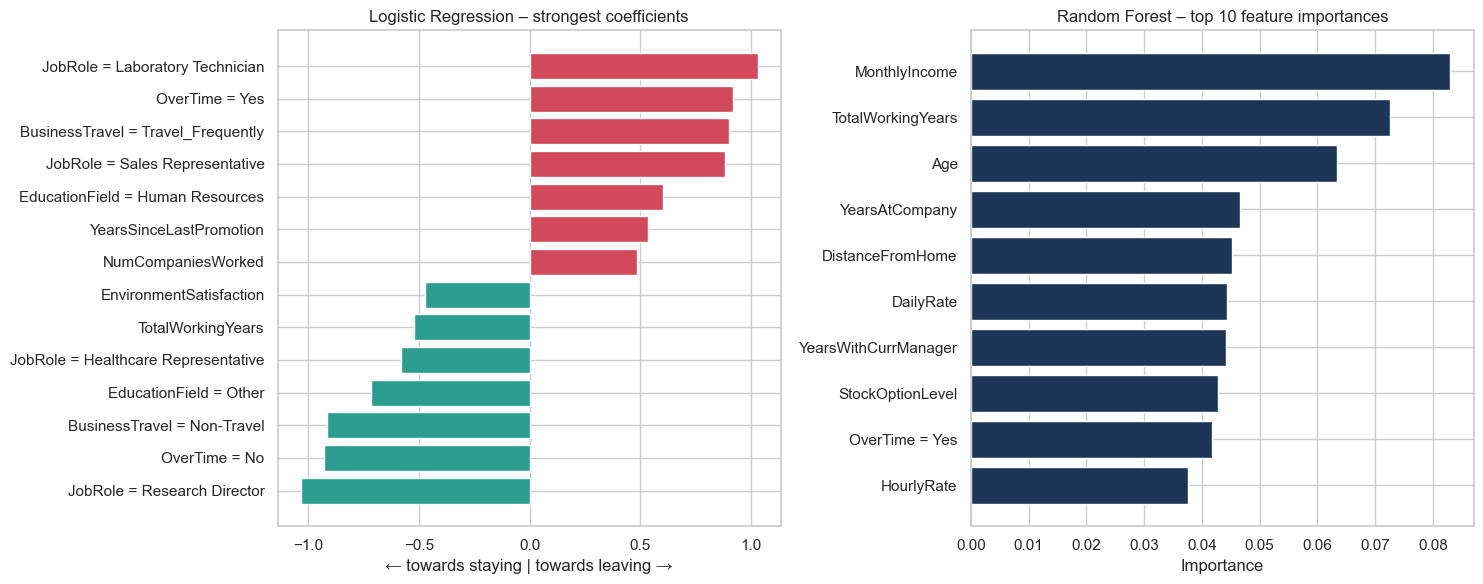

In [27]:
def readable(names):
    """Tidy ColumnTransformer feature names, e.g. 'cat__OverTime_Yes' -> 'OverTime = Yes'."""
    out = []
    for n in names:
        n = n.split("__", 1)[1]
        for c in cat_cols:
            if n.startswith(c + "_"):
                n = f"{c} = {n[len(c) + 1:]}"
                break
        out.append(n)
    return out


lr_pipe, rf_pipe = tuned_models["Logistic Regression"], tuned_models["Random Forest"]
feat_names = readable(lr_pipe.named_steps["prep"].get_feature_names_out())
coef = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=feat_names)
coef_top = pd.concat([coef.nsmallest(7), coef.nlargest(7)]).sort_values()
importance = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=feat_names).nlargest(10).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.barh(coef_top.index, coef_top.values, color=np.where(coef_top.values > 0, COLORS["Leaves"], COLORS["Stays"]))
ax1.set(title="Logistic Regression – strongest coefficients", xlabel="← towards staying | towards leaving →")
ax2.barh(importance.index, importance.values, color="#1d3557")
ax2.set(title="Random Forest – top 10 feature importances", xlabel="Importance")
plt.tight_layout()
plt.show()

* **Logistic Regression** points to clear, actionable risk factors: **working overtime**, **frequent business travel**, the **Laboratory Technician / Sales Representative** roles and **years since the last promotion** increase risk, while being a **Research Director**, **not working overtime**, **not travelling** and **more total working years** reduce it – consistent with the EDA.
* **Random Forest** spreads importance over continuous pay / tenure variables (monthly income, age, total working years, daily / monthly / hourly rate). The rate columns are essentially noise in this dataset, which is one more reason the forest over-fits compared with the simpler linear model.

## 9. Save Models for Streamlit Deployment
The four **tuned** pipelines (preprocessing + model) are stored with `joblib`, one file per model, with the input-column definition. `app.py` loads exactly these files. `summary.json` stores result tables for the report.

In [28]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_FILES = {"Logistic Regression": "logistic_regression.joblib", "Decision Tree": "decision_tree.joblib",
               "Random Forest": "random_forest.joblib", "k-NN": "knn.joblib"}

for name, filename in MODEL_FILES.items():
    joblib.dump(tuned_models[name], MODEL_DIR / filename)
joblib.dump({"features": list(X.columns), "numeric": num_cols, "categorical": cat_cols}, MODEL_DIR / "feature_info.joblib")

summary = {
    "cv_baseline": cv_table.reset_index(names="Model").to_dict("records"),
    "tuning": tuning_df.reset_index().astype({"Best parameters": str}).to_dict("records"),
    "test_baseline": baseline_df.reset_index(names="Model").to_dict("records"),
    "test_tuned": tuned_df.reset_index(names="Model").to_dict("records"),
    "thresholds": threshold_df.reset_index().to_dict("records"),
}
(MODEL_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

for path in sorted(MODEL_DIR.iterdir()):
    print(f"{path.name:<28} {path.stat().st_size / 1024:8.1f} KB")

decision_tree.joblib              9.2 KB
feature_info.joblib               0.6 KB
knn.joblib                      485.3 KB
logistic_regression.joblib        8.0 KB
random_forest.joblib           1146.8 KB
summary.json                      5.8 KB


### 9.1 Reload check and sample predictions

In [29]:
reloaded = {name: joblib.load(MODEL_DIR / f) for name, f in MODEL_FILES.items()}
for name, model in reloaded.items():
    assert (model.predict(X_test) == tuned_models[name].predict(X_test)).all(), name
print("Reload check passed: saved models reproduce the in-memory predictions.\n")

labels = {0: "Stays", 1: "Leaves"}
sample = X_test.iloc[:6]
demo = pd.DataFrame({"Actual": y_test.iloc[:6].map(labels)})
for name, model in reloaded.items():
    demo[name] = pd.Series(model.predict(sample), index=sample.index).map(labels)
demo

Reload check passed: saved models reproduce the in-memory predictions.



,Actual,Logistic Regression,Decision Tree,Random Forest,k-NN
1061,Stays,Stays,Leaves,Leaves,Stays
891,Stays,Stays,Stays,Stays,Stays
456,Stays,Stays,Leaves,Stays,Stays
922,Stays,Stays,Stays,Stays,Stays
69,Leaves,Stays,Stays,Stays,Stays
1164,Stays,Stays,Leaves,Stays,Stays


## 10. Conclusion

**What was done.** A complete machine-learning workflow was applied to the IBM HR Analytics attrition dataset: inspection, in-depth EDA (class balance, attrition rates by category, class-wise distributions, correlations, outliers), preprocessing with one-hot encoding and scaling inside leakage-free pipelines, a stratified 80/20 split, four algorithms (Logistic Regression, Decision Tree, Random Forest, k-NN), stratified 5-fold cross-validation, `GridSearchCV` on all four models, and evaluation with accuracy / precision / recall / F1 / ROC-AUC / PR-AUC, confusion matrices and classification reports.

**Main findings**
* **Overtime, frequent travel, low-level / sales / lab-technician roles, low income and short tenure** are the clearest attrition risk factors.
* **Logistic Regression is the best model** (CV F1 0.561, ROC-AUC 0.812, PR-AUC 0.584). Trees and k-NN over-fit or suffer from the high dimensionality; tuning improved them substantially in cross-validation but not enough to catch the linear model.
* **Accuracy is misleading** for this 16 % problem; moving the decision threshold from 0.5 to 0.25 lifts recall from 34 % to 62 % for the best model – a decision HR can make from the business cost of each error type.

**Limitations.** The data is a fictional IBM sample, a single snapshot (no time dimension), the test set contains only 47 leavers, and the model gives associations, not causes. It must not be used to make individual employment decisions.

**Next step – deployment.** `app.py` loads the four saved models, lets a user describe an employee through grouped inputs, and shows each model's attrition probability and a consensus. Run locally with `streamlit run app.py`; the live Streamlit URL is included in the PDF report.